# 3-Class PAD Classification: ResNet18 | ResNet50 | EfficientNet | InceptionV3
**Classes:** `real` | `attack` (printed) | `E-display`  
**Split:** 80% Train / 10% Val / 10% Test  
**Epochs:** 100 (minimum)  
**Output:** `output_3class_classification/output_3class_<model>/`

## Cell 1 — Imports & Configuration

In [1]:
import os
import copy
import json
import time
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# ─── SEED ───────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─── DEVICE ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ─── PATHS ──────────────────────────────────────────────────────────────────
# !! CHANGE THESE TO YOUR ACTUAL PATHS ON YOUR SERVER !!
DATA_ROOT   = Path('/home/teaching/pad_data_3class')   # parent folder containing real/, attack/, E-display/
OUTPUT_ROOT = Path('/home/teaching/output_3class_classification')

CLASS_NAMES = ['real', 'attack', 'E-display']   # order = label 0, 1, 2
NUM_CLASSES = len(CLASS_NAMES)

# ─── HYPER-PARAMETERS ───────────────────────────────────────────────────────
NUM_EPOCHS   = 100
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT_P    = 0.5

TRAIN_RATIO  = 0.80
VAL_RATIO    = 0.10
TEST_RATIO   = 0.10

# Models to train — comment out any you want to skip
MODELS_TO_TRAIN = ['resnet18', 'resnet50', 'efficientnet', 'inceptionv3']

# Input size per model
MODEL_INPUT_SIZE = {
    'resnet18':    224,
    'resnet50':    224,
    'efficientnet':224,
    'inceptionv3': 299,
}

print(f"\nClasses : {CLASS_NAMES}")
print(f"Data root: {DATA_ROOT}")
print(f"Output  : {OUTPUT_ROOT}")
print(f"Epochs  : {NUM_EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LR}")
print(f"Split   : {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/{int(TEST_RATIO*100)} (train/val/test)")

Device: cuda
  GPU: NVIDIA RTX A5000
  VRAM: 25.4 GB

Classes : ['real', 'attack', 'E-display']
Data root: /home/teaching/pad_data_3class
Output  : /home/teaching/output_3class_classification
Epochs  : 100  |  Batch: 32  |  LR: 0.0001
Split   : 80/10/10 (train/val/test)


## Cell 2 — Data Transforms & Dataset Split

In [2]:
def get_transforms(input_size, is_train=True):
    """Return transforms for a given input size."""
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
    if is_train:
        return transforms.Compose([
            transforms.Resize((input_size + 32, input_size + 32)),
            transforms.RandomCrop(input_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.ColorJitter(
                brightness=0.3, contrast=0.3,
                saturation=0.2, hue=0.1
            ),
            transforms.RandomRotation(15),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        return transforms.Compose([
            transforms.Resize((input_size, input_size)),
            transforms.ToTensor(),
            normalize,
        ])


def make_split_datasets(data_root, input_size,
                         train_ratio=0.80, val_ratio=0.10,
                         seed=SEED):
    """
    Load a flat ImageFolder and perform stratified 80/10/10 split.
    Returns three Dataset objects with their correct transforms.
    """
    full_dataset = datasets.ImageFolder(root=data_root)
    targets = np.array(full_dataset.targets)
    indices = np.arange(len(full_dataset))

    # First split: train vs rest
    idx_train, idx_rest = train_test_split(
        indices, test_size=1 - train_ratio,
        stratify=targets, random_state=seed
    )
    # Second split: val vs test (equal halves of 'rest' → each 10%)
    val_frac_of_rest = val_ratio / (val_ratio + (1 - train_ratio - val_ratio))
    idx_val, idx_test = train_test_split(
        idx_rest, test_size=0.5,
        stratify=targets[idx_rest], random_state=seed
    )

    print(f"  Total images : {len(full_dataset)}")
    print(f"  Train        : {len(idx_train)}")
    print(f"  Val          : {len(idx_val)}")
    print(f"  Test         : {len(idx_test)}")
    print(f"  Class map    : {full_dataset.class_to_idx}")

    # Create three copies with different transforms
    train_ds = copy.deepcopy(full_dataset)
    val_ds   = copy.deepcopy(full_dataset)
    test_ds  = copy.deepcopy(full_dataset)

    train_ds.transform = get_transforms(input_size, is_train=True)
    val_ds.transform   = get_transforms(input_size, is_train=False)
    test_ds.transform  = get_transforms(input_size, is_train=False)

    return (
        Subset(train_ds, idx_train),
        Subset(val_ds,   idx_val),
        Subset(test_ds,  idx_test),
        full_dataset.class_to_idx,
    )


def make_loaders(train_ds, val_ds, test_ds, batch_size):
    num_workers = min(4, os.cpu_count())
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


print("Transform & split helpers defined ✓")

Transform & split helpers defined ✓


## Cell 3 — Model Factory

In [3]:
def build_model(model_name: str, num_classes: int, dropout_p: float = 0.5):
    """
    Build a pretrained model with its classifier head replaced
    for `num_classes` outputs.
    """
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'inceptionv3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        model.aux_logits = True                        # keep aux during training
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )
        # Also replace auxiliary classifier head
        aux_in = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(aux_in, num_classes)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {model_name}: total={total_params:,}  trainable={trainable_params:,}")
    return model


print("Model factory defined ✓")

Model factory defined ✓


## Cell 4 — Training Loop (with early stopping & best-model saving)

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device, is_inception=False):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        if is_inception:
            outputs, aux_outputs = model(inputs)
            loss = criterion(outputs, labels) + 0.4 * criterion(aux_outputs, labels)
        else:
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        probs  = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
        all_preds .extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs .extend(probs.cpu().numpy())

    return (
        running_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs),
    )


def train_model(model_name, model, train_loader, val_loader,
                num_epochs, lr, weight_decay, output_dir, device):
    """
    Full training loop: trains for num_epochs, saves best val-acc checkpoint,
    returns history dict.
    """
    is_inception = (model_name == 'inceptionv3')
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_val_acc  = 0.0
    best_weights  = None
    history       = defaultdict(list)
    ckpt_path     = output_dir / 'best_model.pth'

    print(f"\n{'='*60}")
    print(f"  Training  :  {model_name.upper()}")
    print(f"  Output dir:  {output_dir}")
    print(f"{'='*60}")

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, is_inception
        )
        val_loss, val_acc, _, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        # Save history
        history['epoch'    ].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc' ].append(train_acc)
        history['val_loss'  ].append(val_loss)
        history['val_acc'   ].append(val_acc)
        history['lr'        ].append(current_lr)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, ckpt_path)
            flag = '  ← best'
        else:
            flag = ''

        if epoch % 5 == 0 or epoch == 1:
            elapsed = (time.time() - start_time) / 60
            print(
                f"  Ep {epoch:3d}/{num_epochs}  "
                f"TrLoss={train_loss:.4f}  TrAcc={train_acc:.4f}  "
                f"ValLoss={val_loss:.4f}  ValAcc={val_acc:.4f}  "
                f"LR={current_lr:.2e}  [{elapsed:.1f} min]{flag}"
            )

    total_mins = (time.time() - start_time) / 60
    print(f"\n  Training complete in {total_mins:.1f} min")
    print(f"  Best val accuracy: {best_val_acc:.4f}")

    # Restore best weights
    model.load_state_dict(best_weights)
    return model, history, best_val_acc


print("Training loop defined ✓")

Training loop defined ✓


## Cell 5 — Plotting & Reporting Utilities

In [5]:
def plot_training_curves(history, model_name, output_dir):
    """Loss & Accuracy curves over epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = history['epoch']

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title(f'{model_name} — Loss', fontsize=13)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.4)

    # Accuracy
    axes[1].plot(epochs, [a*100 for a in history['train_acc']],
                 label='Train Acc', color='royalblue')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],
                 label='Val Acc',   color='tomato')
    axes[1].set_title(f'{model_name} — Accuracy', fontsize=13)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    axes[1].legend(); axes[1].grid(True, alpha=0.4)

    plt.suptitle(f'{model_name.upper()} — Training Curves', fontsize=15, y=1.02)
    plt.tight_layout()
    save_path = output_dir / 'training_curves.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")


def plot_confusion_matrix(y_true, y_pred, class_names, model_name, output_dir):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_pct],
        ['d', '.1f'],
        ['Count', 'Percentage (%)'],
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt,
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, linewidths=0.5
        )
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{model_name} — Confusion Matrix ({title})')

    plt.tight_layout()
    save_path = output_dir / 'confusion_matrix.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")


def plot_roc_curves(y_true, y_probs, class_names, model_name, output_dir):
    y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    colors = ['royalblue', 'tomato', 'seagreen']

    plt.figure(figsize=(8, 6))
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls}  (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name.upper()} — ROC Curves (One-vs-Rest)')
    plt.legend(loc='lower right'); plt.grid(True, alpha=0.4)
    plt.tight_layout()
    save_path = output_dir / 'roc_curves.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")


def save_classification_report(y_true, y_pred, class_names, model_name, output_dir):
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4
    )
    print(f"\n  Classification Report — {model_name.upper()}")
    print(report)
    save_path = output_dir / 'classification_report.txt'
    with open(save_path, 'w') as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Date : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write(report)
    print(f"  Saved: {save_path}")


def save_history_csv(history, output_dir):
    df = pd.DataFrame(history)
    save_path = output_dir / 'training_history.csv'
    df.to_csv(save_path, index=False)
    print(f"  Saved: {save_path}")
    return df


def save_metrics_json(metrics_dict, output_dir):
    save_path = output_dir / 'metrics_summary.json'
    with open(save_path, 'w') as f:
        json.dump(metrics_dict, f, indent=2)
    print(f"  Saved: {save_path}")


print("Plotting & reporting utilities defined ✓")

Plotting & reporting utilities defined ✓


## Cell 6 — Master Run: Train All 4 Models

Output directories:
  resnet18         →  /home/teaching/output_3class_classification/output_3class_resnet18
  resnet50         →  /home/teaching/output_3class_classification/output_3class_resnet50
  efficientnet     →  /home/teaching/output_3class_classification/output_3class_efficientnet
  inceptionv3      →  /home/teaching/output_3class_classification/output_3class_inceptionv3


#################################################################
#  MODEL: RESNET18                                           #
#################################################################

[1] Building datasets (input_size=224) ...
  Total images : 17699
  Train        : 14159
  Val          : 1770
  Test         : 1770
  Class map    : {'E-display': 0, 'attack': 1, 'real': 2}

[2] Building model ...
  resnet18: total=11,178,051  trainable=11,178,051

[3] Training for 100 epochs ...

  Training  :  RESNET18
  Output dir:  /home/teaching/output_3class_classification/output_3class_resnet18
  Ep   1/100 

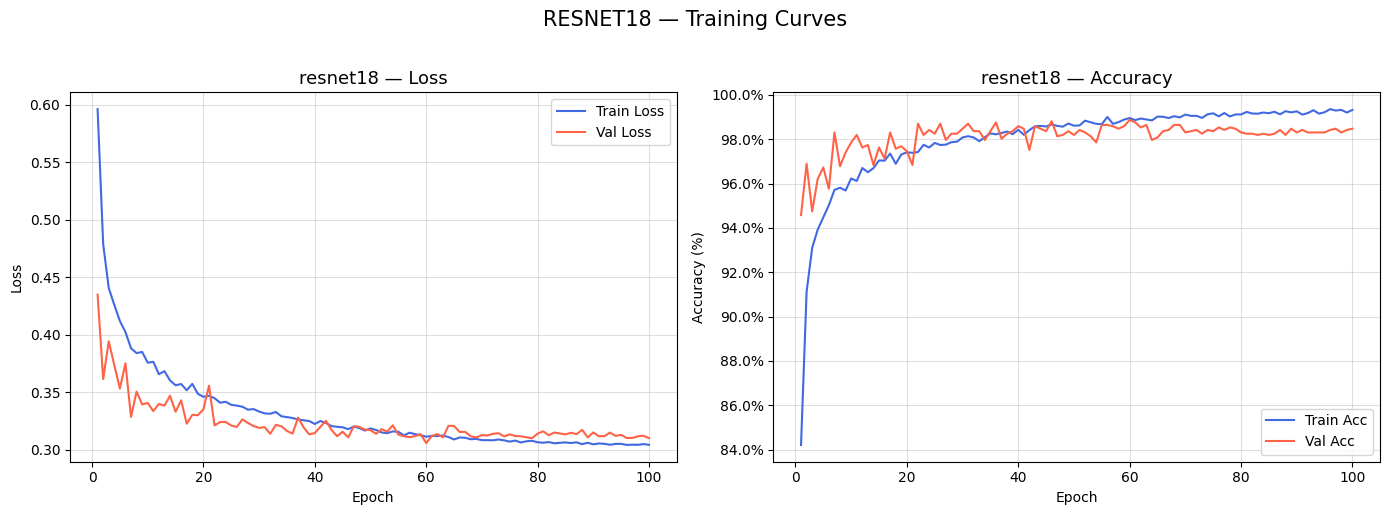

  Saved: /home/teaching/output_3class_classification/output_3class_resnet18/training_curves.png


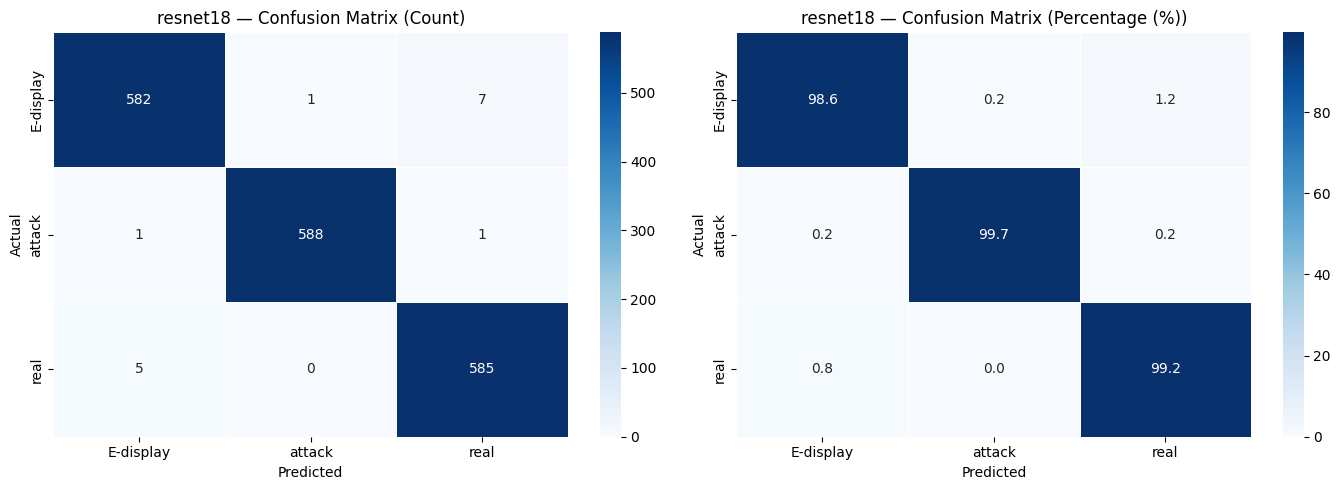

  Saved: /home/teaching/output_3class_classification/output_3class_resnet18/confusion_matrix.png


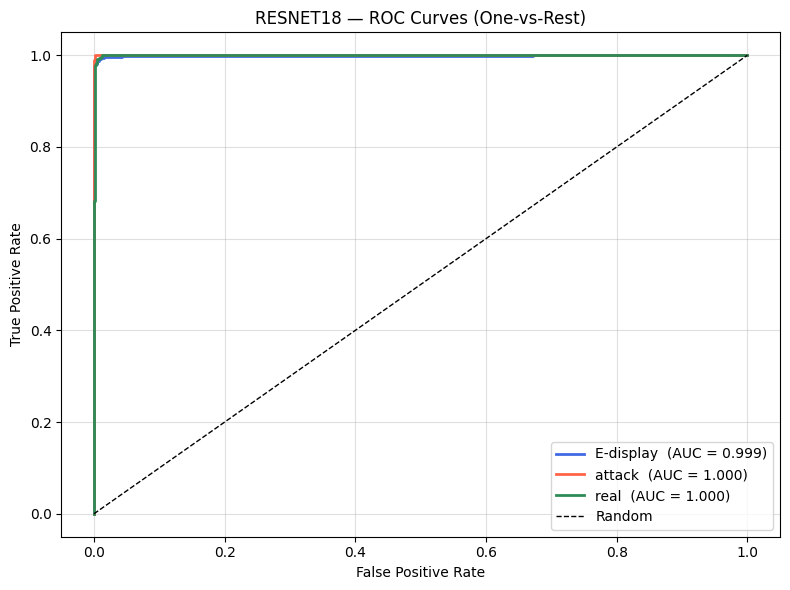

  Saved: /home/teaching/output_3class_classification/output_3class_resnet18/roc_curves.png

  Classification Report — RESNET18
              precision    recall  f1-score   support

   E-display     0.9898    0.9864    0.9881       590
      attack     0.9983    0.9966    0.9975       590
        real     0.9865    0.9915    0.9890       590

    accuracy                         0.9915      1770
   macro avg     0.9915    0.9915    0.9915      1770
weighted avg     0.9915    0.9915    0.9915      1770

  Saved: /home/teaching/output_3class_classification/output_3class_resnet18/classification_report.txt
  Saved: /home/teaching/output_3class_classification/output_3class_resnet18/training_history.csv
  Saved: /home/teaching/output_3class_classification/output_3class_resnet18/metrics_summary.json

  ✓ RESNET18 done.


#################################################################
#  MODEL: RESNET50                                           #
#############################################

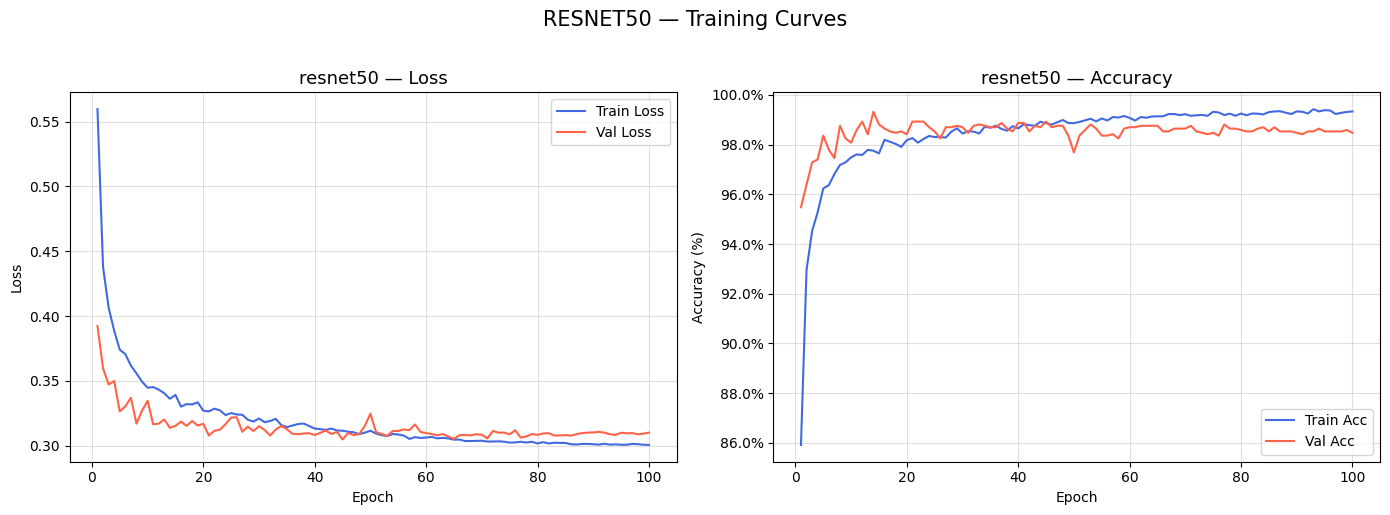

  Saved: /home/teaching/output_3class_classification/output_3class_resnet50/training_curves.png


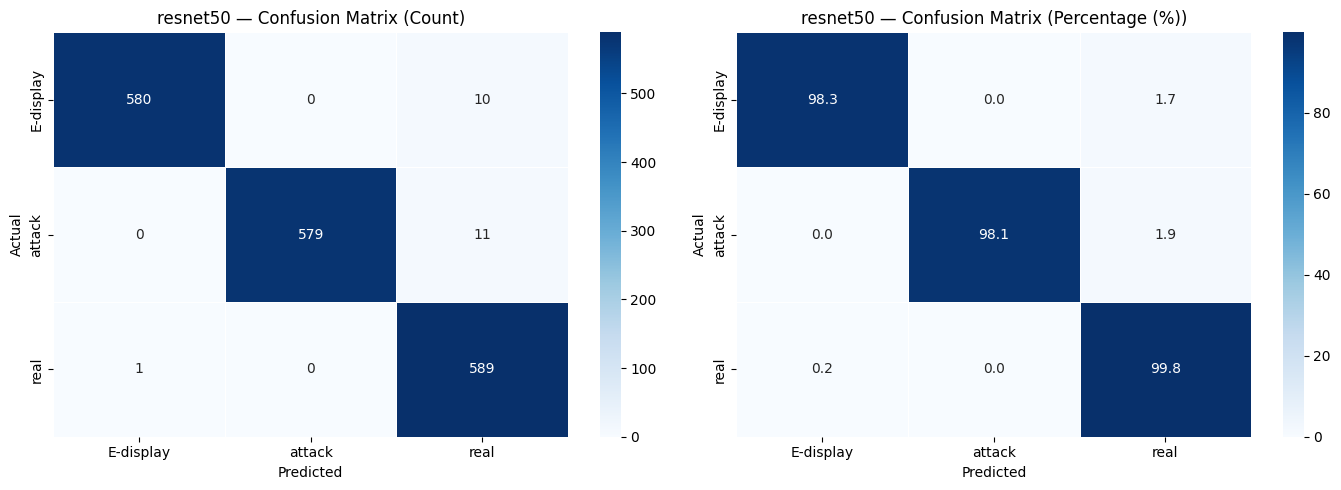

  Saved: /home/teaching/output_3class_classification/output_3class_resnet50/confusion_matrix.png


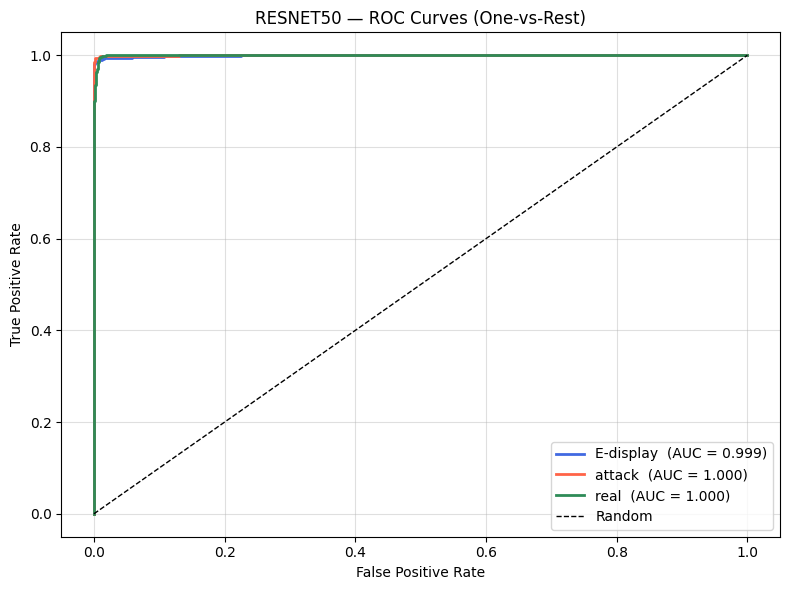

  Saved: /home/teaching/output_3class_classification/output_3class_resnet50/roc_curves.png

  Classification Report — RESNET50
              precision    recall  f1-score   support

   E-display     0.9983    0.9831    0.9906       590
      attack     1.0000    0.9814    0.9906       590
        real     0.9656    0.9983    0.9817       590

    accuracy                         0.9876      1770
   macro avg     0.9880    0.9876    0.9876      1770
weighted avg     0.9880    0.9876    0.9876      1770

  Saved: /home/teaching/output_3class_classification/output_3class_resnet50/classification_report.txt
  Saved: /home/teaching/output_3class_classification/output_3class_resnet50/training_history.csv
  Saved: /home/teaching/output_3class_classification/output_3class_resnet50/metrics_summary.json

  ✓ RESNET50 done.


#################################################################
#  MODEL: EFFICIENTNET                                       #
#############################################

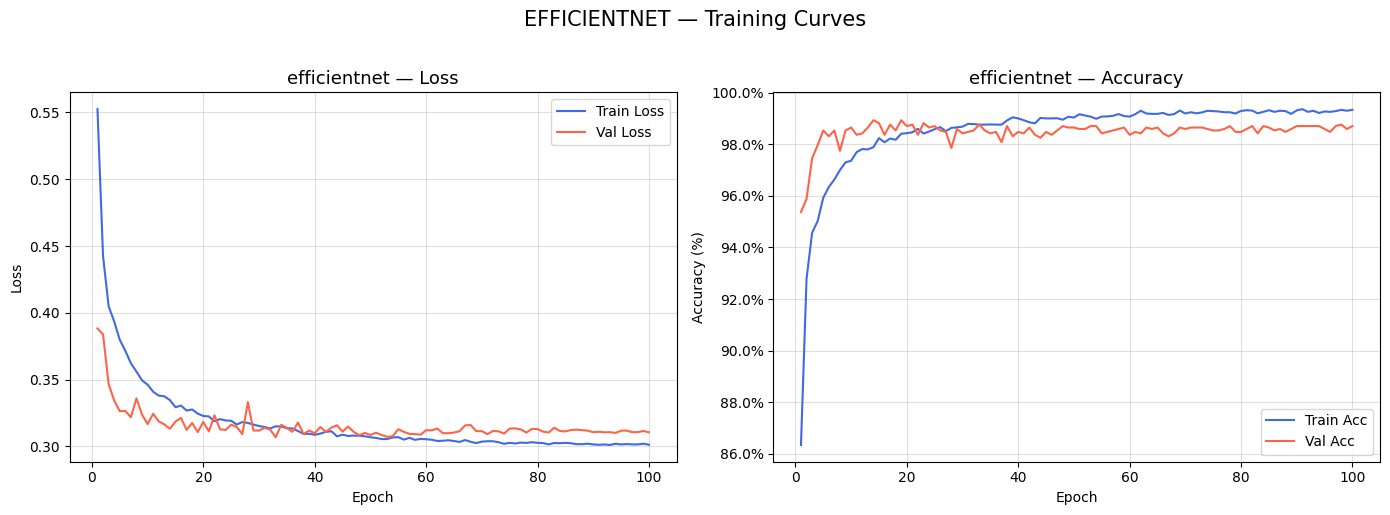

  Saved: /home/teaching/output_3class_classification/output_3class_efficientnet/training_curves.png


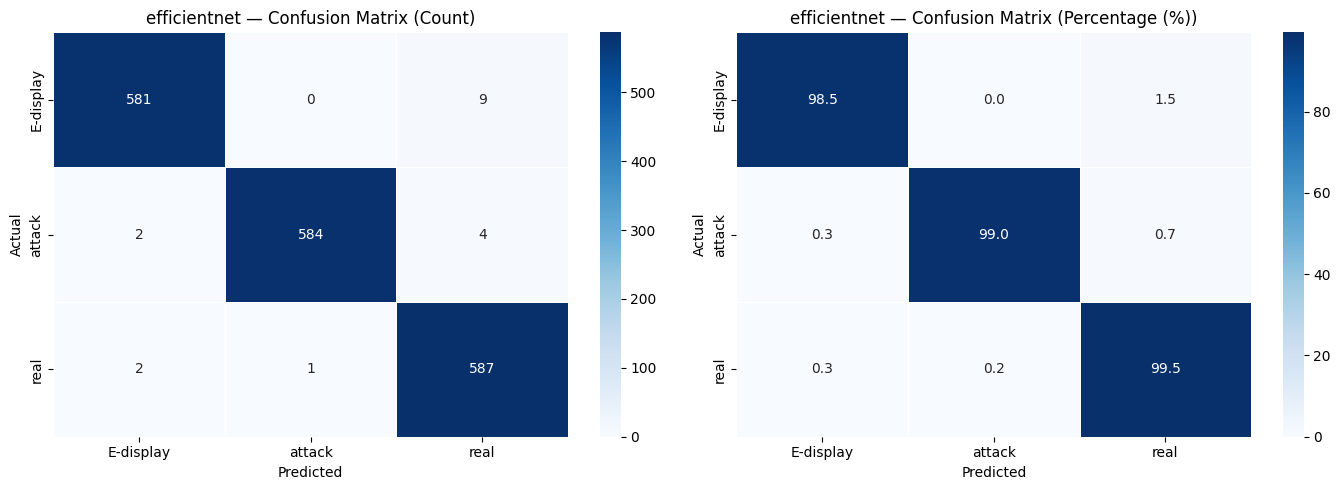

  Saved: /home/teaching/output_3class_classification/output_3class_efficientnet/confusion_matrix.png


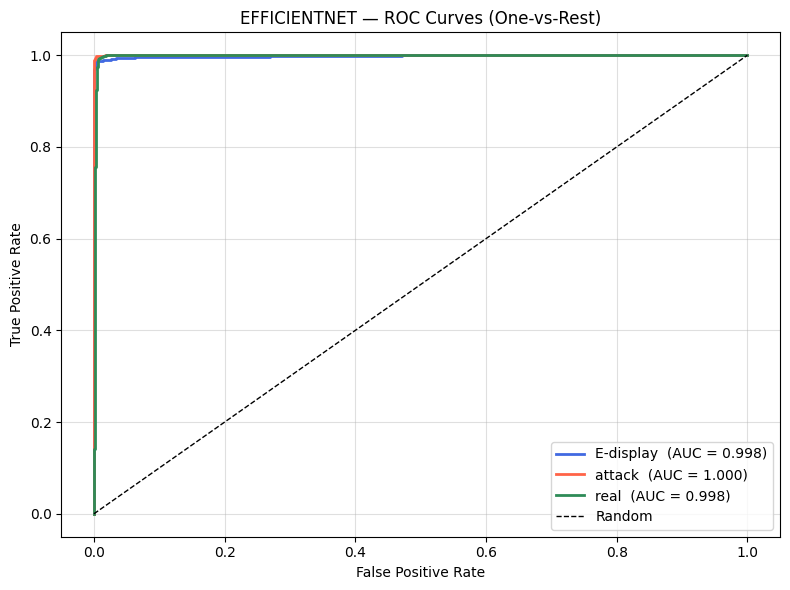

  Saved: /home/teaching/output_3class_classification/output_3class_efficientnet/roc_curves.png

  Classification Report — EFFICIENTNET
              precision    recall  f1-score   support

   E-display     0.9932    0.9847    0.9889       590
      attack     0.9983    0.9898    0.9940       590
        real     0.9783    0.9949    0.9866       590

    accuracy                         0.9898      1770
   macro avg     0.9899    0.9898    0.9898      1770
weighted avg     0.9899    0.9898    0.9898      1770

  Saved: /home/teaching/output_3class_classification/output_3class_efficientnet/classification_report.txt
  Saved: /home/teaching/output_3class_classification/output_3class_efficientnet/training_history.csv
  Saved: /home/teaching/output_3class_classification/output_3class_efficientnet/metrics_summary.json

  ✓ EFFICIENTNET done.


#################################################################
#  MODEL: INCEPTIONV3                                        #
#####################

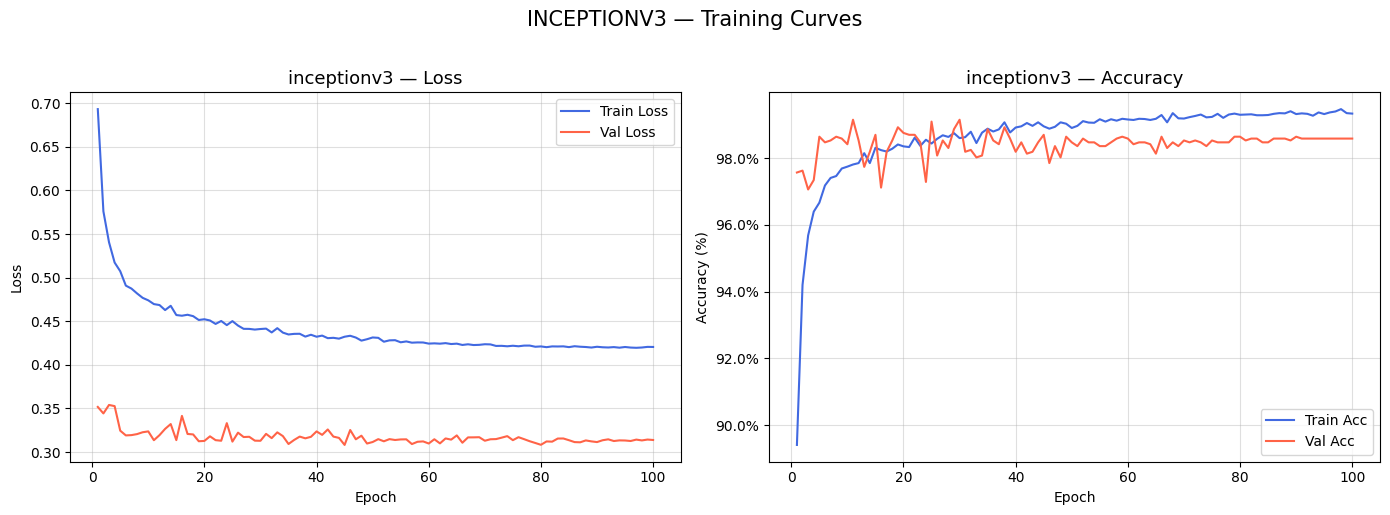

  Saved: /home/teaching/output_3class_classification/output_3class_inceptionv3/training_curves.png


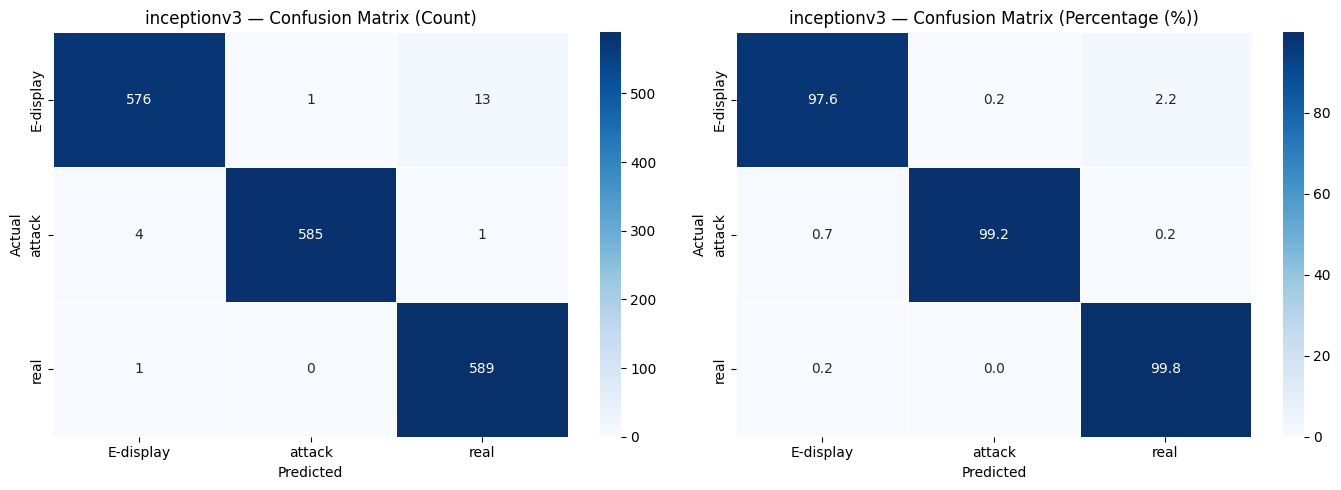

  Saved: /home/teaching/output_3class_classification/output_3class_inceptionv3/confusion_matrix.png


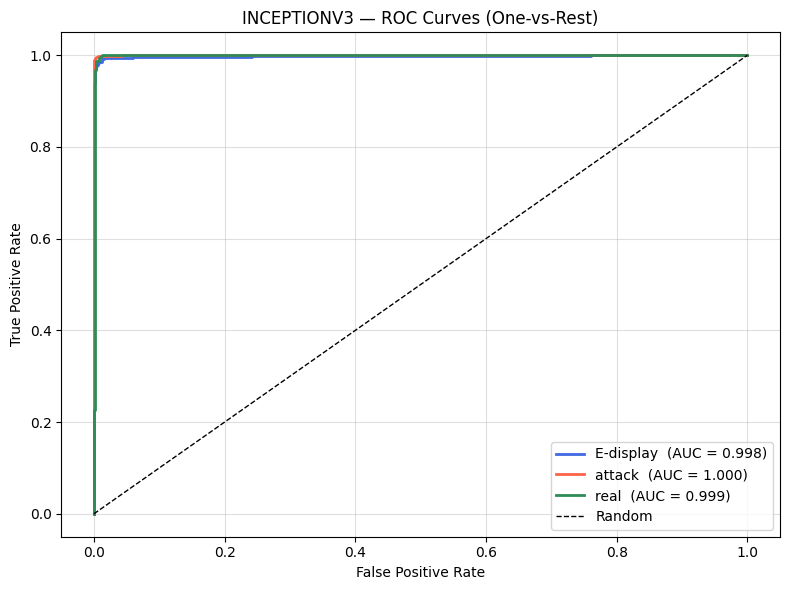

  Saved: /home/teaching/output_3class_classification/output_3class_inceptionv3/roc_curves.png

  Classification Report — INCEPTIONV3
              precision    recall  f1-score   support

   E-display     0.9914    0.9763    0.9838       590
      attack     0.9983    0.9915    0.9949       590
        real     0.9768    0.9983    0.9874       590

    accuracy                         0.9887      1770
   macro avg     0.9888    0.9887    0.9887      1770
weighted avg     0.9888    0.9887    0.9887      1770

  Saved: /home/teaching/output_3class_classification/output_3class_inceptionv3/classification_report.txt
  Saved: /home/teaching/output_3class_classification/output_3class_inceptionv3/training_history.csv
  Saved: /home/teaching/output_3class_classification/output_3class_inceptionv3/metrics_summary.json

  ✓ INCEPTIONV3 done.


  ALL MODELS TRAINED


In [6]:
# ─── Output folder map ───────────────────────────────────────────────────────
MODEL_OUTPUT_DIRS = {
    'resnet18'    : OUTPUT_ROOT / 'output_3class_resnet18',
    'resnet50'    : OUTPUT_ROOT / 'output_3class_resnet50',
    'efficientnet': OUTPUT_ROOT / 'output_3class_efficientnet',
    'inceptionv3' : OUTPUT_ROOT / 'output_3class_inceptionv3',
}

# Create all output directories
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
for d in MODEL_OUTPUT_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("Output directories:")
for k, v in MODEL_OUTPUT_DIRS.items():
    print(f"  {k:15s}  →  {v}")

# ─── Global summary collector ────────────────────────────────────────────────
all_model_metrics = {}

# ════════════════════════════════════════════════════════════════════════════
#  MAIN LOOP
# ════════════════════════════════════════════════════════════════════════════
for model_name in MODELS_TO_TRAIN:
    print(f"\n\n{'#'*65}")
    print(f"#  MODEL: {model_name.upper():<50} #")
    print(f"{'#'*65}")

    output_dir = MODEL_OUTPUT_DIRS[model_name]
    input_size = MODEL_INPUT_SIZE[model_name]

    # ── 1. Data ──────────────────────────────────────────────────────────────
    print(f"\n[1] Building datasets (input_size={input_size}) ...")
    train_ds, val_ds, test_ds, class_to_idx = make_split_datasets(
        DATA_ROOT, input_size,
        train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO
    )
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    ordered_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

    train_loader, val_loader, test_loader = make_loaders(
        train_ds, val_ds, test_ds, BATCH_SIZE
    )

    # ── 2. Build model ────────────────────────────────────────────────────────
    print(f"\n[2] Building model ...")
    model = build_model(model_name, NUM_CLASSES, DROPOUT_P).to(DEVICE)

    # ── 3. Train ──────────────────────────────────────────────────────────────
    print(f"\n[3] Training for {NUM_EPOCHS} epochs ...")
    model, history, best_val_acc = train_model(
        model_name, model,
        train_loader, val_loader,
        NUM_EPOCHS, LR, WEIGHT_DECAY,
        output_dir, DEVICE
    )

    # ── 4. Evaluate on test set ───────────────────────────────────────────────
    print(f"\n[4] Evaluating on TEST set ...")
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, y_pred, y_true, y_probs = evaluate(
        model, test_loader, criterion, DEVICE
    )
    print(f"  Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

    # AUC
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    try:
        macro_auc = roc_auc_score(y_bin, y_probs, multi_class='ovr', average='macro')
    except Exception:
        macro_auc = float('nan')
    print(f"  Macro AUC : {macro_auc:.4f}")

    # ── 5. Save all outputs ───────────────────────────────────────────────────
    print(f"\n[5] Saving outputs to {output_dir} ...")
    plot_training_curves(history, model_name, output_dir)
    plot_confusion_matrix(y_true, y_pred, ordered_names, model_name, output_dir)
    plot_roc_curves(y_true, y_probs, ordered_names, model_name, output_dir)
    save_classification_report(y_true, y_pred, ordered_names, model_name, output_dir)
    save_history_csv(history, output_dir)

    metrics = {
        'model'        : model_name,
        'best_val_acc' : round(best_val_acc, 4),
        'test_loss'    : round(test_loss, 4),
        'test_accuracy': round(test_acc, 4),
        'macro_auc'    : round(macro_auc, 4) if not np.isnan(macro_auc) else None,
        'epochs_trained': NUM_EPOCHS,
        'timestamp'    : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
    save_metrics_json(metrics, output_dir)
    all_model_metrics[model_name] = metrics

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()
    print(f"\n  ✓ {model_name.upper()} done.")


print(f"\n\n{'='*65}")
print("  ALL MODELS TRAINED")
print(f"{'='*65}")

## Cell 7 — Comparative Summary Table & Bar Chart


  FINAL COMPARISON SUMMARY
       Model Best Val Acc Test Accuracy Macro AUC
    resnet18       98.87%        99.15%    0.9994
    resnet50       99.32%        98.76%    0.9995
efficientnet       98.93%        98.98%    0.9989
 inceptionv3       99.15%        98.87%    0.9990

  Saved summary: /home/teaching/output_3class_classification/all_models_summary.csv


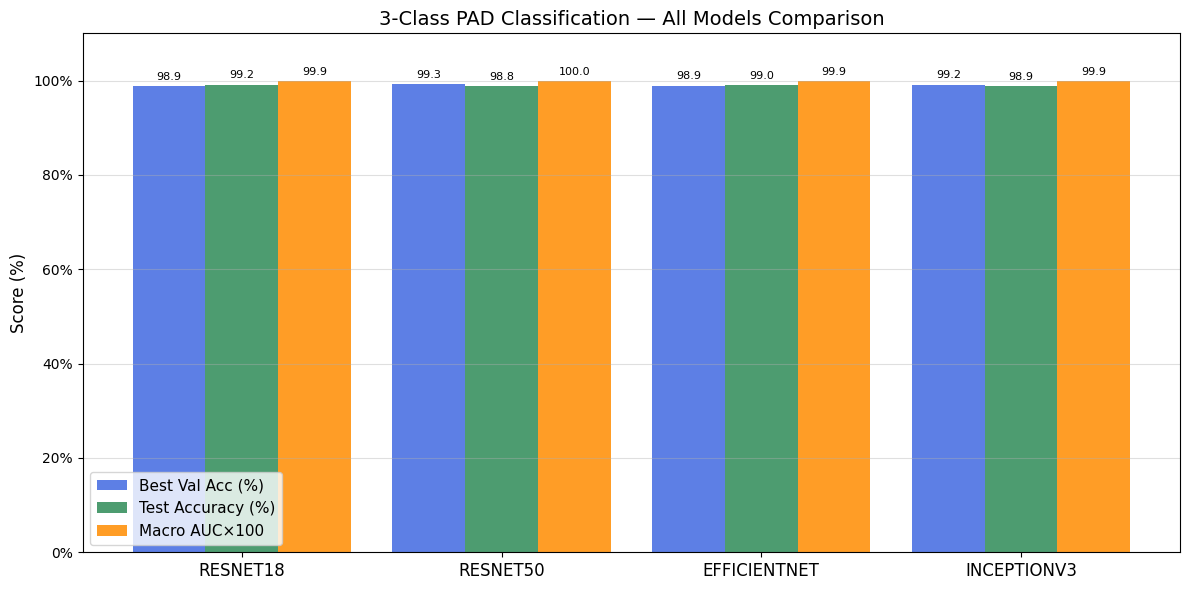

  Saved chart: /home/teaching/output_3class_classification/all_models_comparison.png


In [7]:
# ── Summary table ────────────────────────────────────────────────────────────
summary_rows = []
for mname, m in all_model_metrics.items():
    summary_rows.append({
        'Model'         : mname,
        'Best Val Acc'  : f"{m['best_val_acc']*100:.2f}%",
        'Test Accuracy' : f"{m['test_accuracy']*100:.2f}%",
        'Macro AUC'     : f"{m['macro_auc']:.4f}" if m['macro_auc'] else 'N/A',
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*55)
print("  FINAL COMPARISON SUMMARY")
print("="*55)
print(summary_df.to_string(index=False))

# Save summary CSV
summary_csv = OUTPUT_ROOT / 'all_models_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(f"\n  Saved summary: {summary_csv}")

# ── Bar chart comparison ─────────────────────────────────────────────────────
model_names   = list(all_model_metrics.keys())
test_accs     = [all_model_metrics[m]['test_accuracy'] * 100 for m in model_names]
best_val_accs = [all_model_metrics[m]['best_val_acc']  * 100 for m in model_names]
macro_aucs    = [
    (all_model_metrics[m]['macro_auc'] or 0) * 100
    for m in model_names
]

x = np.arange(len(model_names))
width = 0.28

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, best_val_accs, width, label='Best Val Acc (%)',  color='royalblue',  alpha=0.85)
b2 = ax.bar(x,          test_accs,    width, label='Test Accuracy (%)', color='seagreen',   alpha=0.85)
b3 = ax.bar(x + width,  macro_aucs,   width, label='Macro AUC×100',     color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in model_names], fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('3-Class PAD Classification — All Models Comparison', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', alpha=0.4)

for bar_group in [b1, b2, b3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
chart_path = OUTPUT_ROOT / 'all_models_comparison.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved chart: {chart_path}")

## Cell 8 — Verify Output Directory Structure

In [8]:
print("\n=== Output File Structure ===")
for root, dirs, files in os.walk(OUTPUT_ROOT):
    level = root.replace(str(OUTPUT_ROOT), '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = '  ' * (level + 1)
    for fname in sorted(files):
        fpath = Path(root) / fname
        size  = fpath.stat().st_size
        print(f"{subindent}{fname}  ({size/1024:.1f} KB)")


=== Output File Structure ===
output_3class_classification/
  all_models_comparison.png  (65.6 KB)
  all_models_summary.csv  (0.2 KB)
  output_3class_resnet50/
    best_model.pth  (92163.4 KB)
    classification_report.txt  (0.4 KB)
    confusion_matrix.png  (60.4 KB)
    metrics_summary.json  (0.2 KB)
    roc_curves.png  (66.2 KB)
    training_curves.png  (121.8 KB)
    training_history.csv  (9.9 KB)
  output_3class_efficientnet/
    best_model.pth  (15961.6 KB)
    classification_report.txt  (0.4 KB)
    confusion_matrix.png  (61.5 KB)
    metrics_summary.json  (0.2 KB)
    roc_curves.png  (66.8 KB)
    training_curves.png  (120.2 KB)
    training_history.csv  (10.0 KB)
  output_3class_inceptionv3/
    best_model.pth  (95463.3 KB)
    classification_report.txt  (0.4 KB)
    confusion_matrix.png  (59.2 KB)
    metrics_summary.json  (0.2 KB)
    roc_curves.png  (67.1 KB)
    training_curves.png  (124.7 KB)
    training_history.csv  (10.0 KB)
  output_3class_resnet18/
    best_model.pt